In [ ]:
from typing import Any, Optional
from arcengine import GameAction


from arcengine import FrameDataRaw
import json

from arc import MyArcSession
from arc_agi import OperationMode
from arc_agi import Arcade
import logging
import numpy as np
from dotenv import load_dotenv
from PIL import Image
from sandbox import SandboxOrchestrator
from google.genai import types
from google import genai
from tools import TOOL_LIST, SYSTEM_PROMPT, TAKE_ACTION
from agent import JackAgent
import io

load_dotenv()


PALETTE = np.array(
    [
        [0xFF, 0xFF, 0xFF],
        [0xCC, 0xCC, 0xCC],
        [0x99, 0x99, 0x99],
        [0x66, 0x66, 0x66],
        [0x33, 0x33, 0x33],
        [0x00, 0x00, 0x00],
        [0xE5, 0x3A, 0xA3],
        [0xFF, 0x7B, 0xCC],
        [0xF9, 0x3C, 0x31],
        [0x1E, 0x93, 0xFF],
        [0x88, 0xD8, 0xF1],
        [0xFF, 0xDC, 0x00],
        [0xFF, 0x85, 0x1B],
        [0x92, 0x12, 0x31],
        [0x4F, 0xCC, 0x30],
        [0xA3, 0x56, 0xD6],
    ],
    dtype=np.uint8,
)


def render_frame(frame: np.ndarray) -> Image.Image:
    rgb = PALETTE[np.clip(np.asarray(frame, dtype=np.uint8), 0, 15)]
    return Image.fromarray(rgb).resize((512, 512), Image.NEAREST)


logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S"
)


def current_state_prompt(obs: FrameDataRaw) -> str:
    return f"""Currently playing game: {obs.game_id}. On level #{obs.levels_completed} out of #{obs.win_levels}.

"""


def starting_state_prompt(obs: FrameDataRaw) -> str:
    res = f"""Starting the following game: {obs.game_id}

"""

    return (
        f"New game started. Initial state:\n{json.dumps(obs, indent=2)}\n\n"
        f"The full grid is in /home/agent/state.json. "
        f"Start by calling render_board to see the board, then take actions to explore."
    )

In [2]:

arcade = Arcade(operation_mode=OperationMode("normal"))
scorecard_id: str = arcade.open_scorecard(tags=["jackagent"])
arc_session = MyArcSession(
    game_id=["ls20", "ft09", "vc33"][0], arcade=arcade, scorecard_id=scorecard_id
)
sbx = SandboxOrchestrator()
print(sbx.bash("echo sandbox ready"))

agent = JackAgent(sbx=sbx, arc_session=arc_session)


agent.contents = []

2026-04-13 21:09:43 | INFO | Successfully fetched 25 environment(s) from API


21:09:43 Successfully fetched 25 environment(s) from API


2026-04-13 21:09:43 | INFO | Created new scorecard: f1c17b6a-ef1e-4f4b-915a-800c43014309


21:09:43 Created new scorecard: f1c17b6a-ef1e-4f4b-915a-800c43014309


2026-04-13 21:09:43 | INFO | Successfully fetched metadata for game ls20


...

2026-04-13 21:09:43 | INFO | Recording to recordings/f1c17b6a-ef1e-4f4b-915a-800c43014309/ls20-9607627b-99fbe42c-15f9-4b59-a3fe-746ad72ece11.jsonl


21:09:43 Recording to recordings/f1c17b6a-ef1e-4f4b-915a-800c43014309/ls20-9607627b-99fbe42c-15f9-4b59-a3fe-746ad72ece11.jsonl


2026-04-13 21:09:43 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


21:09:43 Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


sandbox ready


In [3]:
# agent.contents = [
#     types.Content(role="user", parts=[types.Part(text=(
#         f"Game: {arc_session.obs.game_id} | "
#         f"Score: {arc_session.obs.levels_completed}/{arc_session.obs.win_levels} | "
#         f"Actions: {[GameAction.from_id(a).name for a in arc_session.obs.available_actions]}\n\n"
#         f"Current grid is in /home/agent/state.json. "
#         f"Full action history is in /home/agent/replay.jsonl.\n\n"
#         f"Workflow:\n"
#         f"1. Render: python3 -c 'from helpers import *; render_board()' then view_image('board.png')\n"
#         f"2. Analyze the grid — find objects, colors, structure, symmetries\n"
#         f"3. Take an action, then render + view again to see what changed\n"
#         f"4. Write your theory of the rules to notes.md — update it as you learn\n"
#         f"5. Use matplotlib to annotate images — draw boxes, arrows, highlights to verify your understanding\n"
#         f"6. Never guess randomly. Build a theory, test it, refine it.\n\n"
#         f"You can create any visualization you want with matplotlib/pillow and see it with view_image. "
#         f"Solve this game."
#     ))])
# ]

# agent.contents.append(types.Content(role="user", parts=[
#     types.Part(text="solve quickly")]))

# for _ in range(100):
#     calls = agent.generate_response()
#     if not calls:
#         last = agent.contents[-1]
#         for p in last.parts:
#             if hasattr(p, "text") and p.text:
#                 print(f"[thinking] {p.text[:300]}\n")
#     for c in calls:
#         print(f"[{c['name']}] {c['args']}")
#         print(f"  → {str(c['result'])[:300]}\n")
#         if c["name"] == "take_action" and agent.arc_session.obs.frame:
#             display(render_frame(agent.arc_session.obs.frame[-1]))
#         if c["name"] == "view_image":
#             try:
#                 raw = agent.sbx.read_file(
#                     agent.sbx._resolve(c["args"]["file_path"]))
#                 display(Image.open(io.BytesIO(raw)))
#             except:
#                 pass

In [4]:
# agent.contents = [
#     types.Content(role="user", parts=[types.Part(text=(
#         "Ignore the game stuff. We're just testing the sandbox.\n\n"
#         "Do these:\n"
#         "1. Write a file /home/agent/matrix.py (~40 lines) that uses numpy and scipy "
#         "to generate a random 10x10 matrix, compute its eigenvalues, and print them sorted.\n"
#         "2. Run it.\n"
#         "3. Use view to read it back. Do the line numbers make sense to you?\n"
#         "4. Use edit to change it — add a line that also prints the determinant. "
#         "Don't rewrite the whole file.\n"
#         "5. Run it again, confirm the determinant shows up.\n"
#         "6. Now deliberately call edit with an old_string that doesn't exist in the file. "
#         "Tell me what error you get back.\n"
#         "7. Write a file /home/agent/viz.py that uses matplotlib to plot the eigenvalues "
#         "as a bar chart and saves it to /home/agent/eigen.png.\n"
#         "8. Run viz.py, then view_image /home/agent/eigen.png.\n"
#         "9. Write a file /home/agent/net.py that uses networkx to create a small graph "
#         "(5 nodes, 7 edges), compute shortest paths, and print them.\n"
#         "10. Run it.\n\n"
#         "After each step, tell me exactly what happened. "
#         "If anything fails or surprises you, say so."
#     ))])
# ]

# for _ in range(40):
#     calls = agent.generate_response()
#     if not calls:
#         last = agent.contents[-1]
#         for p in last.parts:
#             if hasattr(p, "text") and p.text:
#                 print(f"[text] {p.text[:800]}\n")
#         break
#     for c in calls:
#         print(f"[{c['name']}] {str(c['args'])[:200]}")
#         print(f"  → {str(c['result'])[:300]}\n")
#         if c["name"] == "view_image":
#             try:
#                 raw = agent.sbx.read_file(
#                     agent.sbx._resolve(c["args"]["file_path"]))
#                 display(Image.open(io.BytesIO(raw)))
#             except:
#                 pass


21:09:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



21:09:49 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view] {'file_path': '/home/agent/board.png'}
  → Displaying /home/agent/board.png



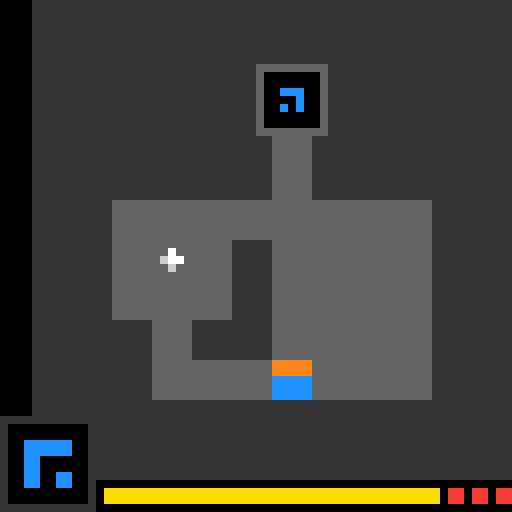

21:09:53 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > test.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\nprint(color_counts(grid))\nEOF\npython3 test.py"}
  → {5: 439, 4: 2609, 3: 892, 9: 45, 0: 3, 1: 2, 12: 10, 11: 84, 8: 12}



21:09:57 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



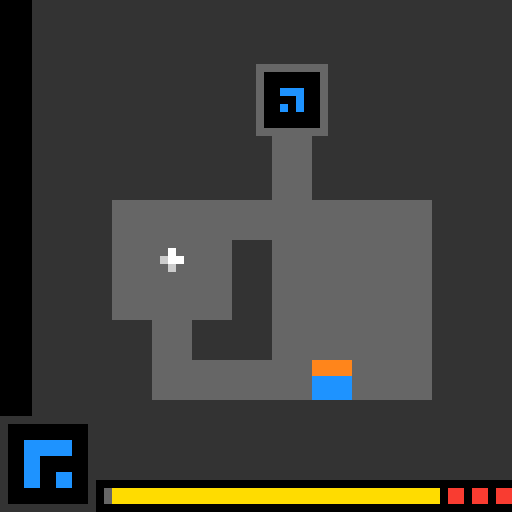

21:10:00 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > test2.py\nfrom helpers import *\nimport json\n\nwith open('replay.jsonl', 'r') as f:\n    events = [json.loads(line) for line in f]\n\ngrid_old = None\n\n# We can't access 
  → no output



21:10:02 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view] {'file_path': '/home/agent/board.png'}
  → Displaying /home/agent/board.png



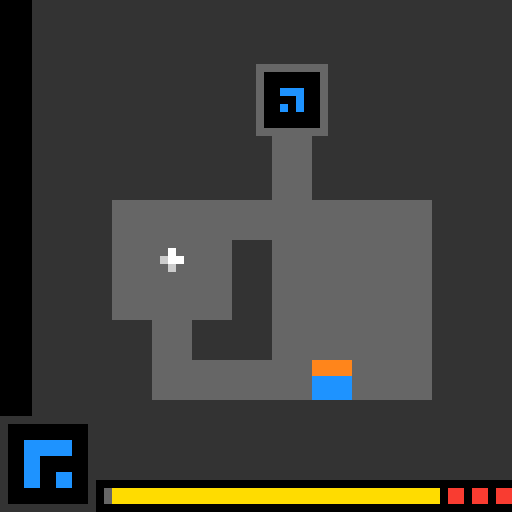

21:10:06 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > compare.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\nprint(find_color(grid, 0))\nEOF\npython3 compare.py"}
  → [(31, 21), (32, 21), (32, 22)]



21:10:08 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; print(find_color(load_grid(), 1))"'}
  → [(32, 20), (33, 21)]



21:10:13 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



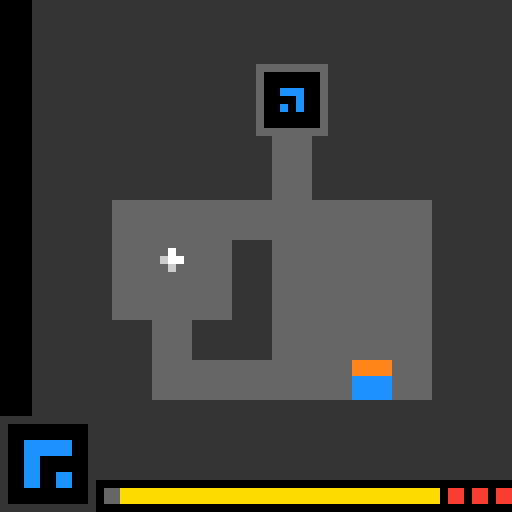

21:10:16 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; print(find_color(load_grid(), 0)); print(find_color(load_grid(), 1))"'}
  → [(31, 21), (32, 21), (32, 22)]
[(32, 20), (33, 21)]



21:10:23 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > map.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\n# find boundaries of 3 (gray)\ngray_cells = np.argwhere(grid == 3)\nmin_r, min_c = gray_cells.min
  → Gray area bounds: 8 13 62 53
Center: 32 21



21:10:27 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > print_grid.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\nsubgrid = grid[25:40, 15:35]\nfor row in subgrid:\n    print("".join(f"{c:2d}" for c in ro
  → 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 3
 3 3 3 3 3 3 0 3 3 3 3 3 3 3 4 4 4 4 4 3
 3 3 3 3 3 1 0



21:10:30 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat replay.jsonl'}
  → {"timestamp": "2026-04-14T01:09:43.626794+00:00", "data": {"game_id": "ls20-9607627b", "state": "NOT_FINISHED", "levels_completed": 0, "win_levels": 7, "action_input": {"id": "RESET", "data": {}, "reasoning": null}, "guid": "99fbe42c-15f9-4b59-a3fe-746ad72ece11", "full_reset": true, "available_actio



21:10:33 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'RESET'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



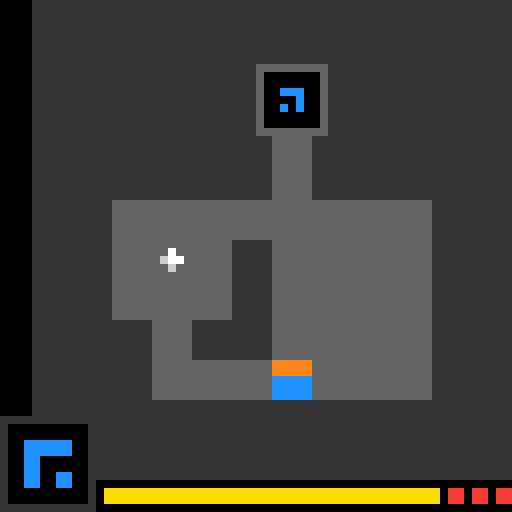

21:10:36 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; print(find_color(load_grid(), 0))"'}
  → [(31, 21), (32, 21), (32, 22)]



21:10:38 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > test_diff.py\nfrom helpers import *\nimport json\n\ngrid_initial = load_grid()\n\nEOF\npython3 test_diff.py"}
  → no output



21:10:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > test_diff.py\nfrom helpers import *\nimport numpy as np\n\ngrid1 = load_grid()\nEOF\npython3 test_diff.py"}
  → no output



21:10:44 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



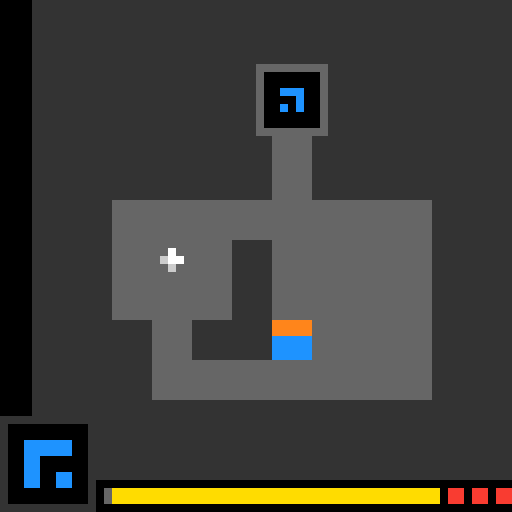

21:10:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > test_diff2.py\nfrom helpers import *\nimport numpy as np\n\n# wait, I didn't save grid1. Let me just take another action and diff.\ngrid1 = load_grid()\nEOF\npython3 test_d
  → no output



21:10:51 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



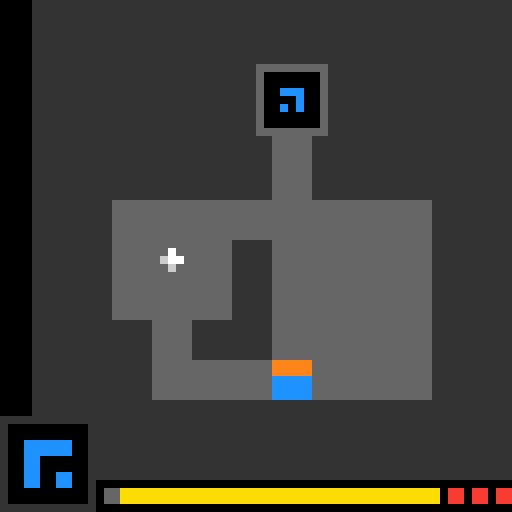

21:10:54 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > test_diff3.py\nfrom helpers import *\nimport numpy as np\n\ngrid2 = load_grid()\nimport test_diff2\ndiff = diff_grids(test_diff2.grid1, grid2)\nprint("Changes:", len(diff
  → Changes: 0



21:11:02 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > print_map.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\nmin_r, min_c = 8, 13\nmax_r, max_c = 62, 53\n\nfor r in range(15, 55, 5):\n    row_str = ""
  → X X X X 5 5 X X X 
X X X X X . X X X 
X . . . . . . . . 
X . . . X . . . . 
X . . . X . . . . 
X X . X X . . . . 
X X . . . O . . . 
X X X X X X X X X



21:11:06 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


...

[bash] {'command': 'cat << \'EOF\' > test_all.py\nimport json\nimport os\nfrom helpers import *\n\nos.system("rm -f replay.jsonl")\nEOF\npython3 test_all.py'}
  → no output



21:11:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > test_all2.py\nfrom helpers import *\n\nres = take_action("RESET")\ng0 = load_grid()\n\nres1 = take_action("ACTION1")\ng1 = load_grid()\nprint("A1 diff:", len(diff_grids(g
  → Traceback (most recent call last):
  File "/home/agent/test_all2.py", line 3, in <module>
    res = take_action("RESET")
          ^^^^^^^^^^^
NameError: name 'take_action' is not defined
Exit code 1



21:11:45 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'RESET'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



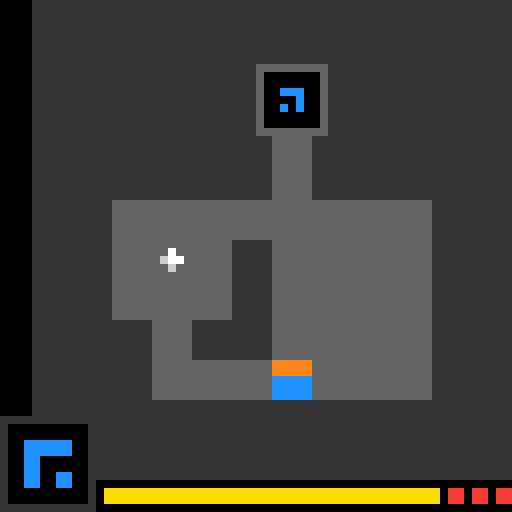

21:11:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cp state.json state0.json'}
  → no output



21:11:49 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



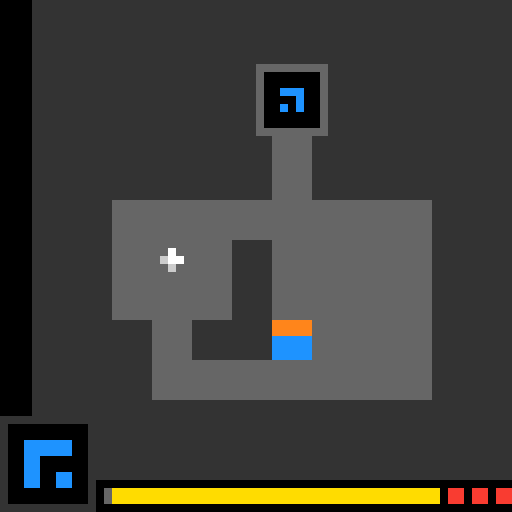

21:11:52 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > diff.py\nimport json\nimport numpy as np\n\ndef load(f): return np.array(json.load(open(f))['grid'])\n\ng0 = load('state0.json')\ng1 = load('state.json')\nd = np.where(g0 !
  → [(np.int64(40), np.int64(34), np.int64(3), np.int64(12)), (np.int64(40), np.int64(35), np.int64(3), np.int64(12)), (np.int64(40), np.int64(36), np.int64(3), np.int64(12)), (np.int64(40), np.int64(37), np.int64(3), np.int64(12)), (np.int64(40), np.int64(38), np.int64(3), np.int64(12)), (np.int64(41),



21:11:55 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cp state.json state1.json'}
  → no output



21:11:58 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



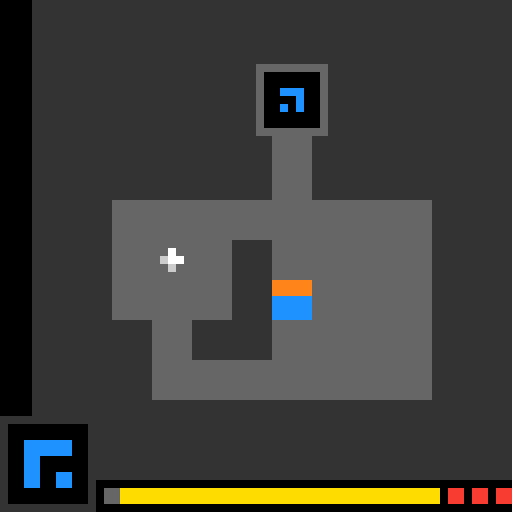

21:12:01 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': "cat << 'EOF' > diff2.py\nimport json\nimport numpy as np\n\ndef load(f): return np.array(json.load(open(f))['grid'])\n\ng0 = load('state1.json')\ng1 = load('state.json')\nd = np.where(g0 
  → [(np.int64(35), np.int64(34), np.int64(3), np.int64(12)), (np.int64(35), np.int64(35), np.int64(3), np.int64(12)), (np.int64(35), np.int64(36), np.int64(3), np.int64(12)), (np.int64(35), np.int64(37), np.int64(3), np.int64(12)), (np.int64(35), np.int64(38), np.int64(3), np.int64(12)), (np.int64(36),



21:12:08 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > print_block_map.py\nfrom helpers import *\nimport numpy as np\n\ngrid = np.array(json.load(open(\'state0.json\'))[\'grid\'])\n\nfor r in range(40, 55, 5):\n    row_str = 
  → X  X  .  . 
 .  .  O  . 
 X  X  X  X



21:12:13 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > downsample.py\nfrom helpers import *\nimport numpy as np\n\ngrid = np.array(json.load(open(\'state0.json\'))[\'grid\'])\n\n# The gray area starts at r=8, c=13? Wait, earl
  → X  X  X  X  X  X  X  X  X 
 X  X  X  X  X  5  X  X  X 
 X  X  X  X  X  .  X  X  X 
 X  X  X  X  X  .  X  X  X 
 X  .  .  .  .  .  .  .  . 
 X  .  .  .  X  .  .  .  . 
 X  .  .  .  X  .  .  .  . 
 X  X  .  X  X  .  .  .  . 
 X  X  .  .  .  B  .  .  . 
 X  X  X  X  X  X  X  X  X 
 X  X  X  X  X  X  X 



21:12:19 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > offset.py\nfrom helpers import *\nimport numpy as np\n\ngrid = np.array(json.load(open(\'state0.json\'))[\'grid\'])\n# find boundaries of 3 (gray)\ngray_cells = np.argwhe
  → Gray area bounds: 8 14 49 53
Orange block: (45, 34)
Player: (31, 21)



21:12:27 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > print_exact.py\nfrom helpers import *\nimport numpy as np\n\ngrid = np.array(json.load(open(\'state0.json\'))[\'grid\'])\n\nfor r in range(0, 55, 5):\n    row_str = ""\n 
  → r= 0:  X  X  X  X  X  X  X  X  X  X 
r= 5:  X  X  X  X  X  X  X  X  X  X 
r=10:  X  X  X  X  X  X  5  X  X  X 
r=15:  X  X  X  X  X  X  .  X  X  X 
r=20:  X  X  X  X  X  X  .  X  X  X 
r=25:  X  X  .  .  .  .  .  .  .  . 
r=30:  X  X  .  .  .  X  .  .  .  . 
r=35:  X  X  .  .  .  X  .  .  .  . 
r=40



In [ ]:
agent.contents = [
    types.Content(role="user", parts=[types.Part(text=(
        f"Game: {arc_session.obs.game_id} | "
        f"Score: {arc_session.obs.levels_completed}/{arc_session.obs.win_levels} | "
        f"Actions: {[GameAction.from_id(a).name for a in arc_session.obs.available_actions]}\n\n"
        f"Current grid is in /home/agent/state.json. "
        f"Full action history is in /home/agent/replay.jsonl.\n\n"
        f"Render the board, look at it, figure out the rules, solve the game."
        f"make a plan and do multiple moves seqwunce at at ime if u want u can try an etnire plan using parallel tool calls."
    ))])
]

for _ in range(100):
    calls = agent.generate_response()
    if not calls:
        last = agent.contents[-1]
        for p in last.parts:
            if hasattr(p, "text") and p.text:
                print(f"[text] {p.text[:500]}\n")
    for c in calls:
        print(f"[{c['name']}] {str(c['args'])[:200]}")
        print(f"  → {str(c['result'])[:300]}\n")
        if c["name"] == "take_action" and agent.arc_session.obs.frame:
            display(render_frame(agent.arc_session.obs.frame[-1]))
        if c["name"] == "view" and c["result"].startswith("Displaying"):
            try:
                raw = agent.sbx.read_file(c["args"]["file_path"])
                display(Image.open(io.BytesIO(raw)))
            except:
                pass